### GAN (5 pts)

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision.datasets as datasets
import imageio
import numpy as np
import matplotlib
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from tqdm import tqdm
matplotlib.style.use('ggplot')

In [4]:
# learning parameters
batch_size = 512
epochs = 200
sample_size = 64 # fixed sample size
nz = 128 # latent vector size
k = 1 # number of steps to apply to the discriminator
device = 'cpu'

In [5]:
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,),(0.5,)),
])
to_pil_image = transforms.ToPILImage()

In [6]:
train_data = datasets.MNIST(
    root='../input/data',
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

100.0%
100.0%
100.0%
100.0%


In [9]:
class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()
        self.nz = nz
        self.main = nn.Sequential(
            # вектор шума размером nz 128
            nn.Linear(nz, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            
            nn.Linear(1024, 784),  # 28**2
            nn.Tanh(),  # [-1, 1] т.к. изображения нормализованы
        )
    
    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)

In [10]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.n_input = 784
        self.main = nn.Sequential(
            # 28**2
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(128, 1),
            nn.Sigmoid(),  # вер-ть реального изображения
        )
    
    def forward(self, x):
        x = x.view(-1, 784)
        return self.main(x)

In [11]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)

In [12]:
optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

In [13]:
criterion = nn.BCELoss()

In [14]:
losses_g = []
losses_d = []
images = []

In [15]:
def label_real(size):
    data = torch.ones(size, 1)
    return data.to(device)
def label_fake(size):
    data = torch.zeros(size, 1)
    return data.to(device)

In [16]:
def create_noise(sample_size, nz):
    return torch.randn(sample_size, nz).to(device)

In [17]:
def save_generator_image(image, path):
    save_image(image, path)

In [18]:
def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)
    real_label = label_real(b_size)
    fake_label = label_fake(b_size)
    optimizer.zero_grad()
    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)
    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)
    loss_real.backward()
    loss_fake.backward()
    optimizer.step()
    return loss_real + loss_fake

In [19]:
def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)
    real_label = label_real(b_size)
    optimizer.zero_grad()
    output = discriminator(data_fake)
    loss = criterion(output, real_label)
    loss.backward()
    optimizer.step()
    return loss

In [20]:
noise = create_noise(sample_size, nz)
generator.train()
discriminator.train()

Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Epoch 199 of 200
Generator loss: 1.21537745, Discriminator loss: 1.08080482


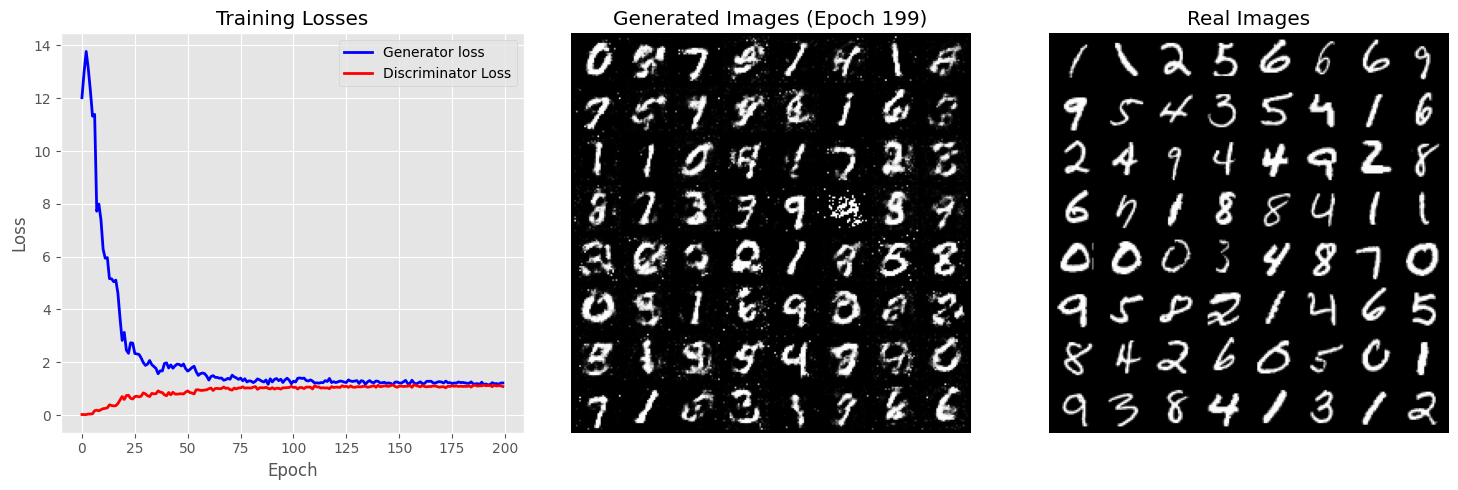

In [25]:
from IPython.display import clear_output

# lists to store losses and images
losses_g = []
losses_d = []
images = []

for epoch in range(epochs):
    loss_g = 0.0
    loss_d = 0.0
    
    for bi, data in enumerate(tqdm(train_loader, desc=f'Epoch {epoch}')):
        image, _ = data
        image = image.to(device)
        b_size = len(image)
        
        # run the discriminator for k number of steps
        for step in range(k):
            data_fake = generator(create_noise(b_size, nz)).detach()
            data_real = image
            # train the discriminator network
            loss_d += train_discriminator(optim_d, data_real, data_fake)
        
        # train the generator network
        data_fake = generator(create_noise(b_size, nz))
        loss_g += train_generator(optim_g, data_fake)
    
    # create the final fake image for the epoch
    generated_img = generator(noise).cpu().detach()
    # make the images as grid
    generated_img = make_grid(generated_img, nrow=8, normalize=True)
    
    images.append(generated_img)
    
    # convert losses to Python numbers
    epoch_loss_g = (loss_g / (bi + 1)).item() if torch.is_tensor(loss_g) else loss_g / (bi + 1)
    epoch_loss_d = (loss_d / (bi + 1)).item() if torch.is_tensor(loss_d) else loss_d / (bi + 1)
    
    # explicitly convert to float
    losses_g.append(float(epoch_loss_g))
    losses_d.append(float(epoch_loss_d))
    
    clear_output(wait=True)
    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")
    
    # create figure for visualization
    plt.figure(figsize=(15, 5))
    
    # plot losses
    plt.subplot(1, 3, 1)
    plt.plot(range(len(losses_g)), losses_g, label='Generator loss', color='blue', linewidth=2)
    plt.plot(range(len(losses_d)), losses_d, label='Discriminator Loss', color='red', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)
    
    # show generated images
    plt.subplot(1, 3, 2)
    plt.imshow(np.transpose(generated_img.numpy(), (1, 2, 0)))
    plt.title(f'Generated Images (Epoch {epoch})')
    plt.axis('off')
    
    # show real images for comparison
    plt.subplot(1, 3, 3)
    real_grid = make_grid(image[:64].cpu(), nrow=8, normalize=True)
    plt.imshow(np.transpose(real_grid.numpy(), (1, 2, 0)))
    plt.title('Real Images')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()